## Machine Learning 1
### Ingeniería Electrónica 

**Semana 3 y 4: Preprocesamiento de Datos Modular, Limpieza, Imputación y Detección de Outliers (Tabulares e Imágenes)** 

---

El éxito de cualquier modelo de **Machine Learning** depende primordialmente de la calidad, limpieza y representatividad de los datos (*"Garbage in, garbage out"*). Los datos recolectados en entornos reales suelen contener ruido, registros faltantes, valores atípicos (outliers) e incoherencias de formato.

En este cuaderno práctico exploraremos el flujo completo de **limpieza y preprocesamiento de datos**, aplicando **código modularizado mediante funciones reutilizables** y **visualizaciones avanzadas con Matplotlib** tanto para datos **tabulares** (obtenidos desde repositorios en línea mediante archivos CSV) como para datos **multimodales/imágenes** (analizando metadatos y detectando imágenes atípicas mediante reducción de dimensionalidad con PCA).

## 1. Datasets de Estudio y Adquisición Automatizada desde Internet

Para garantizar la reproducibilidad y modularidad en ingeniería de datos, encapsularemos la carga y diagnóstico exploratorio inicial en funciones reutilizables. Utilizaremos el dataset **Titanic** obtenido vía URL pública.

| Dataset / Fuente | Tipo de Datos | Tarea de ML | Descripción y Retos de Limpieza |
| :--- | :--- | :--- | :--- |
| **[Titanic Open Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)** | Tabular (CSV) | Clasificación Supervisada | Contiene información demográfica y de billetes de pasajeros. Presenta valores faltantes en `Age`, `Cabin` y `Embarked`, así como outliers numéricos en tarifas (`Fare`). |
| **Lote Multimodal (Imágenes)** | Imágenes RGB/Grises | Análisis de Visión / Calidad | Lote de imágenes con variaciones en resolución, relación de aspecto, artefactos de ruido e imágenes atípicas para análisis de metadatos y PCA. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.ndimage import laplace
from IPython.display import display

# Configuración de estilo global Matplotlib / Seaborn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

def download_and_inspect_csv(url: str) -> pd.DataFrame:
    """
    Descarga un dataset CSV desde una URL pública e imprime un diagnóstico de calidad.
    """
    print(f"Descargando dataset desde: {url} ...")
    df = pd.read_csv(url)
    
    print("\n=================== DIAGNÓSTICO ESTRUCTURAL ===================")
    print(f"Número de Registros (Filas):    {df.shape[0]}")
    print(f"Número de Variables (Columnas): {df.shape[1]}")
    
    # Resumen de nulos y tipos
    summary_df = pd.DataFrame({
        'Tipo_Dato': df.dtypes.astype(str),
        'Nulos': df.isnull().sum(),
        'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Unicos': df.nunique()
    })
    print("\n--- RESUMEN DE VARIABLES Y VALORES FALTANTES ---")
    display(summary_df)
    
    print("\n--- VISTA PREVIA (PRIMERAS 5 FILAS) ---")
    display(df.head(5))
    return df

# Ejecución modularizada
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = download_and_inspect_csv(url_titanic)

Descargando dataset desde: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...

=================== DIAGNÓSTICO ESTRUCTURAL ===================
Número de Registros (Filas):    891
Número de Variables (Columnas): 12

--- RESUMEN DE VARIABLES Y VALORES FALTANTES ---


,Tipo_Dato,Nulos,Porcentaje_Nulos (%),Valores_Unicos
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248



--- VISTA PREVIA (PRIMERAS 5 FILAS) ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Limpieza de Datos Tabulares e Imputación de Valores Faltantes (Modular)

Los datos faltantes se clasifican según su mecanismo de ausencia:
- **MCAR** (*Missing Completely at Random*): Probabilidad de falta totalmente independiente de los datos.
- **MAR** (*Missing at Random*): Probabilidad de falta dependiente de variables observadas.
- **MNAR** (*Missing Not at Random*): Probabilidad de falta dependiente de la variable no observada.

| Método de Imputación | Aplicabilidad | Ventajas | Desventajas |
| :--- | :--- | :--- | :--- |
| **Media / Mediana** | Variables numéricas | Rápido, preserva el tamaño muestral. | Reduce varianza natural y distorsiona correlaciones. |
| **Moda / Categoría Faltante** | Variables categóricas | Preserva la estructura categórica. | Puede sobre-representar la clase dominante. |
| **KNNImputer** | Numéricas complejas | Utiliza relaciones multivariadas entre vecinos. | Mayor costo computacional. |

Registros duplicados eliminados: 0


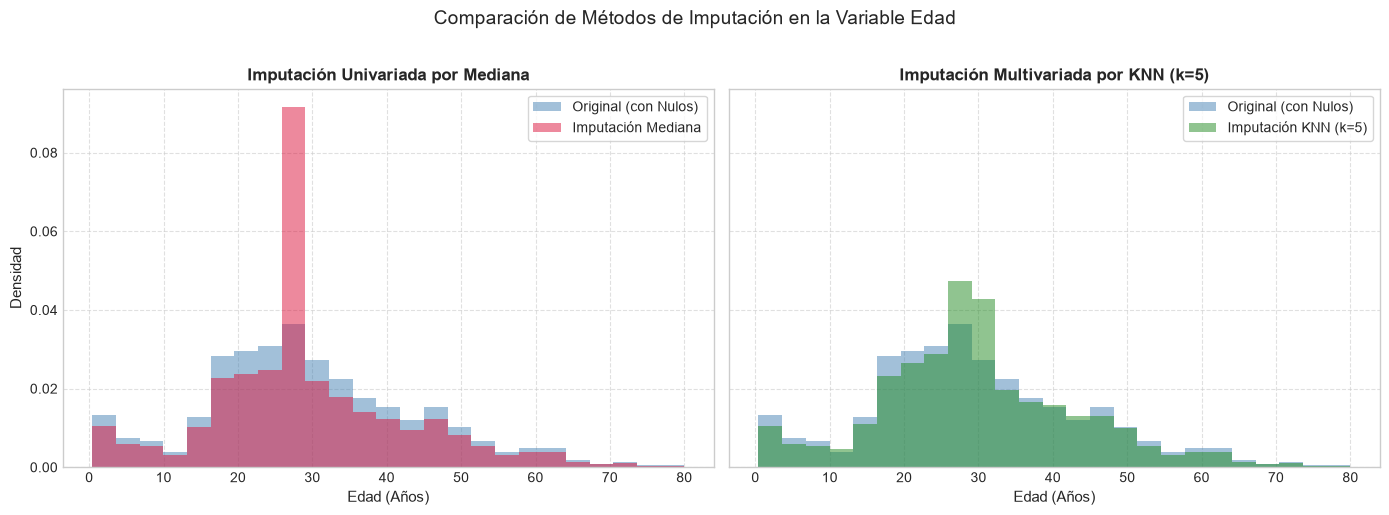

In [2]:
from sklearn.impute import SimpleImputer, KNNImputer

def clean_and_impute_tabular_data(df: pd.DataFrame) -> tuple:
    """
    Limpia duplicados, crea columnas indicadoras e imputa valores numéricos y categóricos.
    """
    df_clean = df.copy()
    
    # 1. Eliminación de duplicados
    num_dups = df_clean.duplicated().sum()
    print(f"Registros duplicados eliminados: {num_dups}")
    if num_dups > 0:
        df_clean.drop_duplicates(inplace=True)
        
    # 2. Creación de variable indicadora de presencia de cabina y descarte de alta cardinalidad
    df_clean['Has_Cabin'] = df_clean['Cabin'].notnull().astype(int)
    df_clean.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)
    
    # 3. Imputación categórica por Moda
    imp_cat = SimpleImputer(strategy='most_frequent')
    df_clean['Embarked'] = imp_cat.fit_transform(df_clean[['Embarked']]).ravel()
    
    # 4. Imputación numérica comparativa de Edad (Mediana vs. KNN)
    imp_med = SimpleImputer(strategy='median')
    df_clean['Age_Median'] = imp_med.fit_transform(df_clean[['Age']])
    
    num_cols = ['Pclass', 'SibSp', 'Parch', 'Fare', 'Age']
    knn_imp = KNNImputer(n_neighbors=5)
    df_knn = pd.DataFrame(knn_imp.fit_transform(df_clean[num_cols]), columns=num_cols)
    df_clean['Age_KNN'] = df_knn['Age']
    
    return df_clean

def plot_imputation_comparison_matplotlib(df_clean: pd.DataFrame):
    """
    Genera un gráfico comparativo de histogramas y KDE utilizando Matplotlib.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    # Subplot 1: Imputación por Mediana
    axes[0].hist(df_clean['Age'].dropna(), bins=25, alpha=0.5, color='steelblue', label='Original (con Nulos)', density=True)
    axes[0].hist(df_clean['Age_Median'], bins=25, alpha=0.5, color='crimson', label='Imputación Mediana', density=True)
    axes[0].set_title('Imputación Univariada por Mediana', fontweight='bold')
    axes[0].set_xlabel('Edad (Años)')
    axes[0].set_ylabel('Densidad')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(frameon=True, facecolor='white')
    
    # Subplot 2: Imputación por KNN
    axes[1].hist(df_clean['Age'].dropna(), bins=25, alpha=0.5, color='steelblue', label='Original (con Nulos)', density=True)
    axes[1].hist(df_clean['Age_KNN'], bins=25, alpha=0.5, color='forestgreen', label='Imputación KNN (k=5)', density=True)
    axes[1].set_title('Imputación Multivariada por KNN (k=5)', fontweight='bold')
    axes[1].set_xlabel('Edad (Años)')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(frameon=True, facecolor='white')
    
    plt.suptitle('Comparación de Métodos de Imputación en la Variable Edad', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecución modularizada
df_clean = clean_and_impute_tabular_data(df_raw)
plot_imputation_comparison_matplotlib(df_clean)

# Fijar Edad final con KNN
df_clean['Age'] = df_clean['Age_KNN']
df_clean.drop(columns=['Age_Median', 'Age_KNN'], inplace=True)

## 3. Identificación y Tratamiento de Outliers en Datos Numéricos

Los valores atípicos (*outliers*) son registros que se alejan significativamente del comportamiento habitual.

| Método de Detección | Criterio Matemático | Ámbito de Uso | Sensibilidad |
| :--- | :--- | :--- | :--- |
| **Z-Score** | $Z = \frac{x - \mu}{\sigma}$, Outlier si $|Z| > 3$ | Datos Gaussiano/Normales. | Sensible a outliers en $\mu$ y $\sigma$. |
| **IQR (Rango Intercuartílico)** | $x < Q_1 - 1.5 \cdot IQR$ o $x > Q_3 + 1.5 \cdot IQR$ | Datos asimétricos o sesgados. | Robusto frente a valores extremos. |
| **Isolation Forest** | Aislamiento en espacio multivariado mediante árboles. | Multivariado y alta dimensión. | Capta interacciones atípicas complejas. |

Outliers detectados por Z-Score (>3): 20
Outliers detectados por IQR (Límite Super = 65.63): 116
Outliers detectados por Isolation Forest: 45


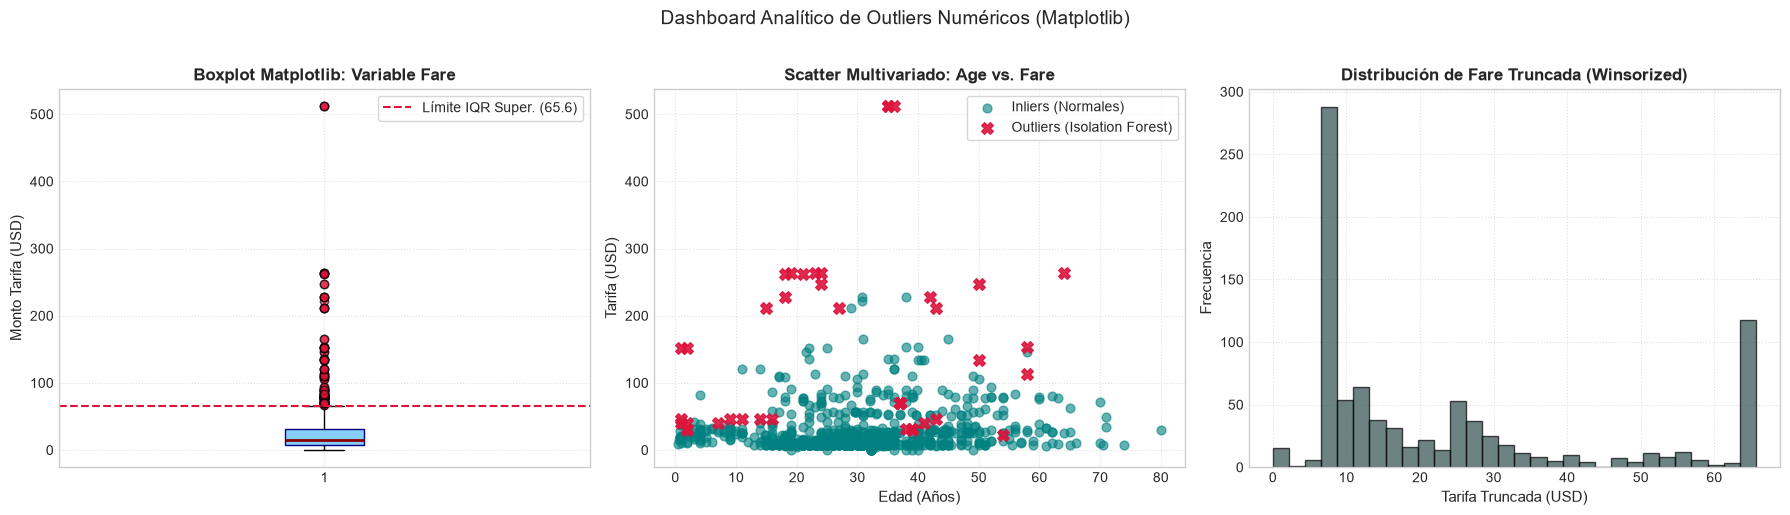

In [3]:
from scipy import stats
from sklearn.ensemble import IsolationForest

def detect_numerical_outliers(df: pd.DataFrame, target_col: str) -> dict:
    """
    Calcula outliers mediante Z-Score, IQR e Isolation Forest.
    """
    # 1. Z-Score
    z_scores = np.abs(stats.zscore(df[target_col]))
    idx_z = df.index[z_scores > 3].tolist()
    
    # 2. IQR
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 1.5 * IQR
    upper_b = Q3 + 1.5 * IQR
    idx_iqr = df[(df[target_col] < lower_b) | (df[target_col] > upper_b)].index.tolist()
    
    # 3. Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    preds = iso.fit_predict(df[['Age', 'Fare', 'SibSp', 'Parch']])
    idx_iso = df.index[preds == -1].tolist()
    
    return {
        'z_outliers': idx_z,
        'iqr_outliers': idx_iqr,
        'iso_outliers': idx_iso,
        'upper_bound': upper_b,
        'lower_bound': lower_b,
        'iso_preds': preds
    }

def plot_outliers_matplotlib_dashboard(df: pd.DataFrame, results: dict, target_col: str):
    """
    Genera un dashboard de 3 paneles con Matplotlib puro para visualización de outliers.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Boxplot Matplotlib de Fare con límite IQR
    axes[0].boxplot(df[target_col], patch_artist=True,
                    boxprops=dict(facecolor='lightskyblue', color='navy'),
                    medianprops=dict(color='darkred', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6, alpha=0.6))
    axes[0].axhline(results['upper_bound'], color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Límite IQR Super. ({results["upper_bound"]:.1f})')
    axes[0].set_title(f'Boxplot Matplotlib: Variable {target_col}', fontweight='bold')
    axes[0].set_ylabel('Monto Tarifa (USD)')
    axes[0].legend(loc='upper right', frameon=True)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # Panel 2: Scatter Plot Multivariado Matplotlib (Age vs. Fare)
    is_iso_outlier = results['iso_preds'] == -1
    axes[1].scatter(df['Age'][~is_iso_outlier], df[target_col][~is_iso_outlier],
                    c='teal', alpha=0.6, s=40, label='Inliers (Normales)')
    axes[1].scatter(df['Age'][is_iso_outlier], df[target_col][is_iso_outlier],
                    c='crimson', alpha=0.9, s=70, marker='X', label='Outliers (Isolation Forest)')
    axes[1].set_title('Scatter Multivariado: Age vs. Fare', fontweight='bold')
    axes[1].set_xlabel('Edad (Años)')
    axes[1].set_ylabel('Tarifa (USD)')
    axes[1].legend(loc='upper right', frameon=True)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    # Panel 3: Truncamiento (Winsorización) Matplotlib Histogram
    fare_winsorized = np.clip(df[target_col], results['lower_bound'], results['upper_bound'])
    axes[2].hist(fare_winsorized, bins=30, color='darkslategrey', edgecolor='black', alpha=0.7)
    axes[2].set_title('Distribución de Fare Truncada (Winsorized)', fontweight='bold')
    axes[2].set_xlabel('Tarifa Truncada (USD)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    
    plt.suptitle('Dashboard Analítico de Outliers Numéricos (Matplotlib)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecución modularizada
outlier_res = detect_numerical_outliers(df_clean, 'Fare')
print(f"Outliers detectados por Z-Score (>3): {len(outlier_res['z_outliers'])}")
print(f"Outliers detectados por IQR (Límite Super = {outlier_res['upper_bound']:.2f}): {len(outlier_res['iqr_outliers'])}")
print(f"Outliers detectados por Isolation Forest: {len(outlier_res['iso_outliers'])}")

plot_outliers_matplotlib_dashboard(df_clean, outlier_res, 'Fare')

## 4. Análisis y Estudio de Imágenes mediante Metadatos (Modular)

En visión por computadora y procesamiento de señales, el diagnóstico de calidad a nivel de **metadatos** previene sesgos en redes neuronales.

| Propiedad / Metadato | Definición / Métrica | Relevancia en Preprocesamiento |
| :--- | :--- | :--- |
| **Dimensiones / Aspect Ratio** | Ancho ($W$), Alto ($H$) y Relación de Aspecto ($W/H$) | Homogeneización (resizing/cropping) para entradas fijas. |
| **Espacio de Color / Canales** | RGB (3 canales), Grises (1 canal), RGBA (4 canales) | Identificación de formato o canales alpha no deseados. |
| **Brillo y Contraste** | Intensidad media ($\mu_I$) y Desviación Estándar ($\sigma_I$) | Detección de imágenes subexpuestas (oscuras) o sobreexpuestas (brillantes). |
| **Varianza del Laplaciano** | $Var(\nabla^2 I)$ | Métrica de nitidez/enfoque para descartar imágenes borrosas. |

--- RESUMEN DE METADATOS EXTRAÍDOS ---


,Image_ID,Height,Width,Aspect_Ratio,Channels,Mean_Brightness,Std_Brightness,Blur_Score,Status_Real
0,img_00,64,256,4.0,3,124.41,43.31,16489.12,Normal
1,img_01,64,256,4.0,3,124.63,43.06,16230.58,Normal
2,img_02,64,256,4.0,3,124.37,43.15,16274.76,Normal
3,img_03,256,128,0.5,3,124.56,43.31,16532.18,Normal
4,img_04,256,128,0.5,3,124.51,43.25,16681.37,Normal
5,img_05,64,256,4.0,3,6.98,4.32,164.59,Outlier (Muy Oscura)
6,img_06,64,64,1.0,3,125.01,43.11,16015.45,Normal
7,img_07,64,64,1.0,3,124.20,43.21,15715.53,Normal
8,img_08,64,256,4.0,3,124.39,43.28,16484.35,Normal
9,img_09,256,128,0.5,3,124.30,43.30,16681.80,Normal


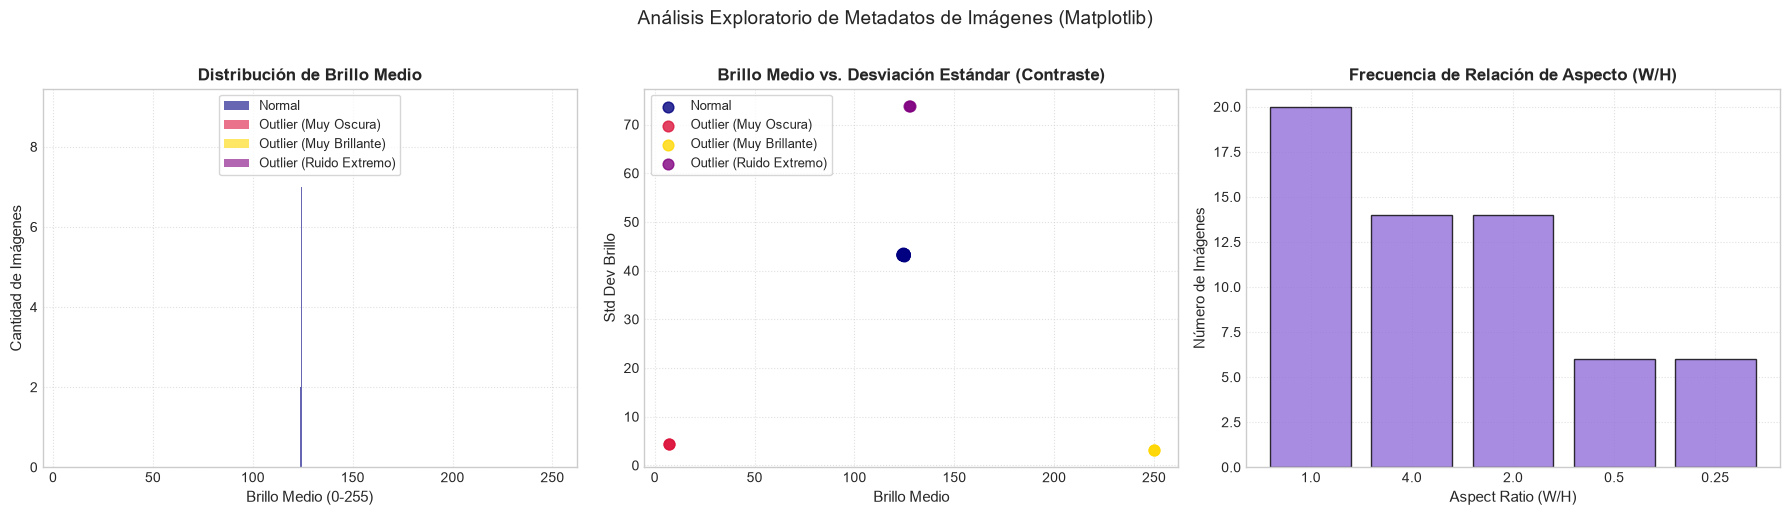

In [4]:
def create_synthetic_image_batch(n_samples: int = 60, seed: int = 42) -> tuple:
    """
    Genera un lote heterogéneo de imágenes sintéticas e inyecta anomalías deliberadas.
    """
    np.random.seed(seed)
    image_batch = []
    metadata_list = []
    
    for i in range(n_samples):
        h = np.random.choice([64, 128, 64, 256])
        w = np.random.choice([64, 128, 64, 256])
        
        # Imagen base
        img = np.random.randint(50, 200, (h, w, 3), dtype=np.uint8)
        status = "Normal"
        
        # Inyección de anomalías
        if i in [5, 12]:
            img = np.random.randint(0, 15, (h, w, 3), dtype=np.uint8)
            status = "Outlier (Muy Oscura)"
        elif i in [22, 35]:
            img = np.random.randint(245, 256, (h, w, 3), dtype=np.uint8)
            status = "Outlier (Muy Brillante)"
        elif i in [45, 52]:
            img = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
            status = "Outlier (Ruido Extremo)"
            
        image_batch.append(img)
        
        # Metadatos
        gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
        blur_val = laplace(gray).var()
        
        metadata_list.append({
            'Image_ID': f"img_{i:02d}",
            'Height': h,
            'Width': w,
            'Aspect_Ratio': round(w / h, 2),
            'Channels': img.shape[2],
            'Mean_Brightness': round(img.mean(), 2),
            'Std_Brightness': round(img.std(), 2),
            'Blur_Score': round(blur_val, 2),
            'Status_Real': status
        })
        
    df_meta = pd.DataFrame(metadata_list)
    return image_batch, df_meta

def plot_image_metadata_matplotlib(df_meta: pd.DataFrame):
    """
    Genera gráficos exploratorios de metadatos de imágenes con Matplotlib.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Histograma de Brillo Medio con Matplotlib
    for status, color in zip(df_meta['Status_Real'].unique(), ['navy', 'crimson', 'gold', 'purple']):
        sub = df_meta[df_meta['Status_Real'] == status]
        axes[0].hist(sub['Mean_Brightness'], bins=15, alpha=0.6, color=color, label=status)
    axes[0].set_title('Distribución de Brillo Medio', fontweight='bold')
    axes[0].set_xlabel('Brillo Medio (0-255)')
    axes[0].set_ylabel('Cantidad de Imágenes')
    axes[0].legend(loc='upper center', frameon=True, fontsize=9)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # 2. Scatter Plot: Brillo Medio vs. Desviación Estándar (Contraste)
    for status, color in zip(df_meta['Status_Real'].unique(), ['navy', 'crimson', 'gold', 'purple']):
        sub = df_meta[df_meta['Status_Real'] == status]
        axes[1].scatter(sub['Mean_Brightness'], sub['Std_Brightness'], label=status, color=color, s=60, alpha=0.8)
    axes[1].set_title('Brillo Medio vs. Desviación Estándar (Contraste)', fontweight='bold')
    axes[1].set_xlabel('Brillo Medio')
    axes[1].set_ylabel('Std Dev Brillo')
    axes[1].legend(loc='upper left', frameon=True, fontsize=9)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    # 3. Bar Chart de Frecuencia de Aspect Ratio con Matplotlib
    counts = df_meta['Aspect_Ratio'].value_counts()
    axes[2].bar(counts.index.astype(str), counts.values, color='mediumpurple', edgecolor='black', alpha=0.8)
    axes[2].set_title('Frecuencia de Relación de Aspecto (W/H)', fontweight='bold')
    axes[2].set_xlabel('Aspect Ratio (W/H)')
    axes[2].set_ylabel('Número de Imágenes')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    
    plt.suptitle('Análisis Exploratorio de Metadatos de Imágenes (Matplotlib)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecución modularizada
image_batch, df_meta = create_synthetic_image_batch(60)
print("--- RESUMEN DE METADATOS EXTRAÍDOS ---")
display(df_meta.head(10))

plot_image_metadata_matplotlib(df_meta)

## 5. Detección de Outliers en Imágenes Mediante Reducción de Dimensión con PCA (Modular)

Para conjuntos masivos de imágenes, convertimos cada imagen homogeneizada ($64 \times 64$ px) en un vector unidimensional ($D = 64 \times 64 \times 3 = 12288$). Aplicamos **PCA** para proyectar al espacio latente y calculamos el **Error de Reconstrucción (MSE)**:
$$e_i = \frac{1}{D} \|x_i - \hat{x}_i\|^2$$

| Concepto PCA | Criterio Matemático | Aplicación en Detección de Outliers de Imagen |
| :--- | :--- | :--- |
| **Vectorización (Flattening)** | $x_i \in \mathbb{R}^D$ | Transforma matrices 2D/3D en un vector unidimensional. |
| **Varianza Explicada Acumulada** | $\sum_{k=1}^K \lambda_k / \sum_{j=1}^D \lambda_j$ | Cantidad de información retenida por los $K$ componentes principales. |
| **Error de Reconstrucción (MSE)** | $e_i = \frac{1}{D} \|x_i - \hat{x}_i\|^2$ | Mide la incapacidad de reconstruir una imagen anómala con el modelo base. |

--- RESULTADOS DE DETECCIÓN PCA ---
Umbral de Error de Reconstrucción: 0.4221
Imágenes detectadas como outliers: 0


,Image_ID,Status_Real,Mean_Brightness,PCA_Reconstruction_Error


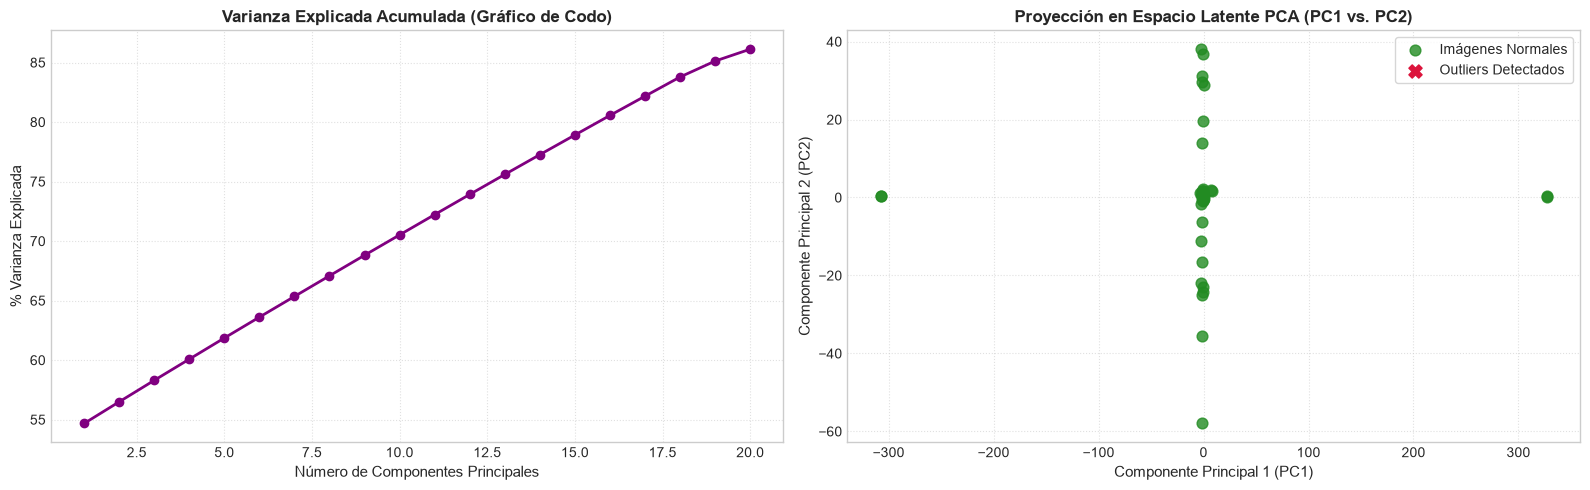

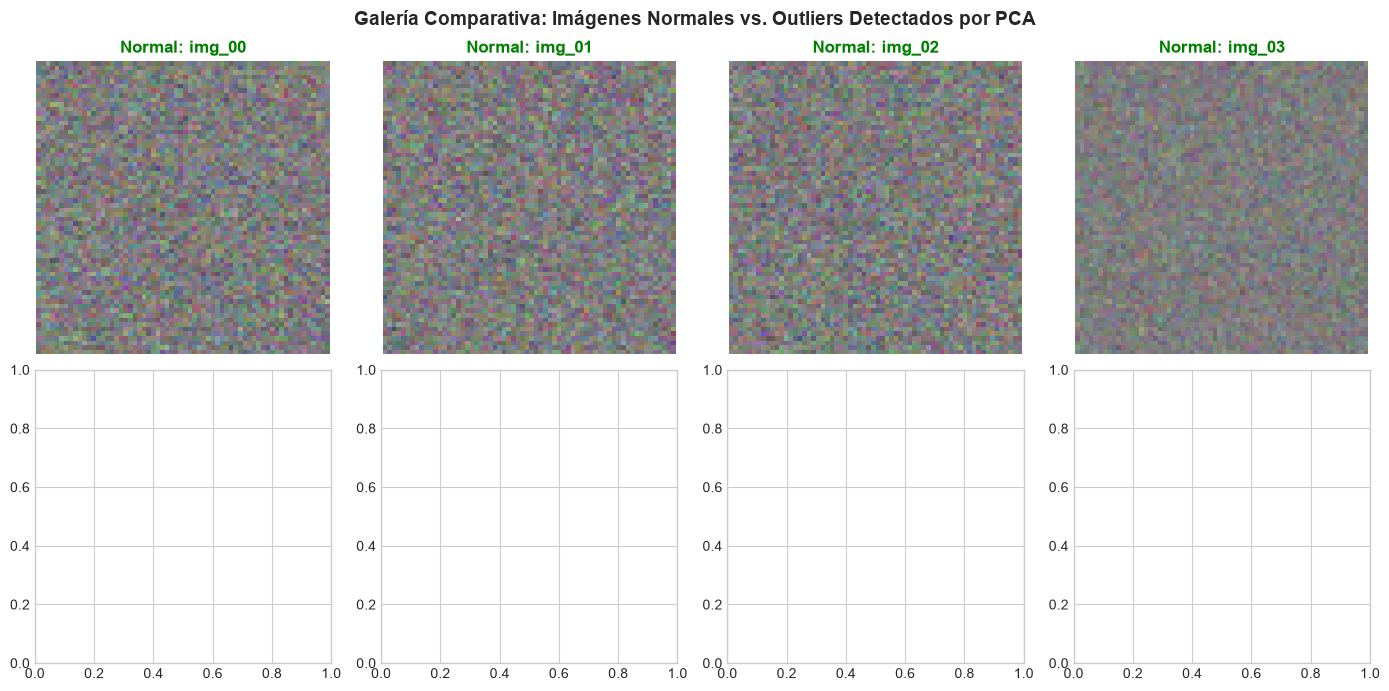

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def detect_image_outliers_pca(image_batch: list, df_meta: pd.DataFrame, target_size=(64, 64), n_components=20) -> tuple:
    """
    Preprocesa, vectoriza, aplica PCA y calcula el error de reconstrucción para detectar outliers de imagen.
    """
    # 1. Estandarización de tamaño con PIL
    resized_imgs = [np.array(Image.fromarray(img).resize(target_size)) for img in image_batch]
    
    # 2. Vectorización (Flattening)
    X_raw = np.array([img.flatten() for img in resized_imgs])
    
    # 3. Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # 4. Ajuste PCA y reconstrucción
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_pca)
    
    # 5. Cálculo del MSE de Reconstrucción
    mse_errors = np.mean(np.square(X_scaled - X_rec), axis=1)
    df_res = df_meta.copy()
    df_res['PCA_Reconstruction_Error'] = mse_errors
    
    threshold = np.mean(mse_errors) + 2 * np.std(mse_errors)
    df_res['PCA_Outlier_Pred'] = df_res['PCA_Reconstruction_Error'] > threshold
    
    return resized_imgs, pca, X_pca, df_res, threshold

def plot_pca_dashboard_and_gallery_matplotlib(resized_imgs: list, pca: PCA, X_pca: np.ndarray, df_res: pd.DataFrame, threshold: float):
    """
    Genera la curva de varianza explicada, scatter 2D PCA y la galería de imágenes detectadas con Matplotlib.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Curva de Varianza Explicada Acumulada
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    axes[0].plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='purple', linewidth=2)
    axes[0].set_title('Varianza Explicada Acumulada (Gráfico de Codo)', fontweight='bold')
    axes[0].set_xlabel('Número de Componentes Principales')
    axes[0].set_ylabel('% Varianza Explicada')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # 2. Scatter Plot Matplotlib PC1 vs. PC2
    is_out = df_res['PCA_Outlier_Pred'].values
    axes[1].scatter(X_pca[~is_out, 0], X_pca[~is_out, 1], c='forestgreen', label='Imágenes Normales', s=60, alpha=0.8)
    axes[1].scatter(X_pca[is_out, 0], X_pca[is_out, 1], c='crimson', label='Outliers Detectados', s=90, marker='X')
    axes[1].set_title('Proyección en Espacio Latente PCA (PC1 vs. PC2)', fontweight='bold')
    axes[1].set_xlabel('Componente Principal 1 (PC1)')
    axes[1].set_ylabel('Componente Principal 2 (PC2)')
    axes[1].legend(loc='upper right', frameon=True)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Galería Comparativa de Imágenes en Matplotlib (Normales vs Outliers)
    normal_idxs = df_res[~df_res['PCA_Outlier_Pred']].index[:4]
    outlier_idxs = df_res[df_res['PCA_Outlier_Pred']].index[:4]
    
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Galería Comparativa: Imágenes Normales vs. Outliers Detectados por PCA', fontsize=14, fontweight='bold')
    
    for idx, n_i in enumerate(normal_idxs):
        axes[0, idx].imshow(resized_imgs[n_i])
        axes[0, idx].set_title(f"Normal: {df_res.loc[n_i, 'Image_ID']}", color='green', fontweight='bold')
        axes[0, idx].axis('off')
        
    for idx, o_i in enumerate(outlier_idxs):
        axes[1, idx].imshow(resized_imgs[o_i])
        axes[1, idx].set_title(f"Outlier: {df_res.loc[o_i, 'Image_ID']}\nErr: {df_res.loc[o_i, 'PCA_Reconstruction_Error']:.2f}", color='red', fontweight='bold')
        axes[1, idx].axis('off')
        
    plt.tight_layout()
    plt.show()

# Ejecución modularizada
resized_imgs, pca_model, X_pca, df_meta_pca, threshold_val = detect_image_outliers_pca(image_batch, df_meta)
print(f"--- RESULTADOS DE DETECCIÓN PCA ---")
print(f"Umbral de Error de Reconstrucción: {threshold_val:.4f}")
print(f"Imágenes detectadas como outliers: {df_meta_pca['PCA_Outlier_Pred'].sum()}")
display(df_meta_pca[df_meta_pca['PCA_Outlier_Pred']][['Image_ID', 'Status_Real', 'Mean_Brightness', 'PCA_Reconstruction_Error']])

plot_pca_dashboard_and_gallery_matplotlib(resized_imgs, pca_model, X_pca, df_meta_pca, threshold_val)

## 6. Pipeline Completo de Preprocesamiento y Buenas Prácticas (Modular)

En entornos de producción, encapsulamos las transformaciones en un `ColumnTransformer` e `Pipeline` reutilizables.

| Etapa del Pipeline | Transformador Utilizado | Propósito |
| :--- | :--- | :--- |
| **Imputación + Escalado Numérico** | `Pipeline([('imputer', MedianImputer), ('scaler', StandardScaler)])` | Normalización continua y limpieza de nulos a media 0 y varianza 1. |
| **Codificación Categórica** | `OneHotEncoder(handle_unknown='ignore')` | Conversión de categorías cualitativas en vectores binarios. |
| **Pipeline Integrado** | `ColumnTransformer(transformers=[...])` | Aplicación paralela atómica a cada tipo de variable. |

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_sklearn_preprocessing_pipeline(num_features: list, cat_features: list) -> ColumnTransformer:
    """
    Construye un ColumnTransformer de Scikit-Learn reutilizable para preprocesamiento tabular.
    """
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])
    return preprocessor

# Ejecución modularizada
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Sex', 'Pclass', 'Embarked']

pipeline_obj = build_sklearn_preprocessing_pipeline(num_cols, cat_cols)
X_processed_matrix = pipeline_obj.fit_transform(df_raw)

# Extraer nombres de características codificadas
cat_encoder_names = pipeline_obj.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_encoder_names)

df_final_preprocessed = pd.DataFrame(X_processed_matrix, columns=all_feature_names)

print("--- MATRIZ FINAL DE CARACTERÍSTICAS LISTA PARA MODELADO ---")
print(f"Dimensiones finales: {df_final_preprocessed.shape}")
display(df_final_preprocessed.head(5))

--- MATRIZ FINAL DE CARACTERÍSTICAS LISTA PARA MODELADO ---
Dimensiones finales: (891, 9)


,Age,Fare,SibSp,Parch,Sex_male,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,-0.565736,-0.502445,0.432793,-0.473674,1.0,0.0,1.0,0.0,1.0
1,0.663861,0.786845,0.432793,-0.473674,0.0,0.0,0.0,0.0,0.0
2,-0.258337,-0.488854,-0.474545,-0.473674,0.0,0.0,1.0,0.0,1.0
3,0.433312,0.420730,0.432793,-0.473674,0.0,0.0,0.0,0.0,1.0
4,0.433312,-0.486337,-0.474545,-0.473674,1.0,0.0,1.0,0.0,1.0


## Resumen Pedagógico y Lista de Cotejo para Proyectos de ML

1. **Modularidad**: Diseñar funciones reutilizables para cada etapa del pipeline.
2. **Visualización Matplotlib**: Personalizar subplots, ejes y leyendas de forma explícita para comunicación técnica clara.
3. **Imputación de Nulos**: Diferenciar MCAR, MAR y MNAR antes de imputar.
4. **Outliers Numéricos**: Utilizar IQR para distribuciones asimétricas e Isolation Forest para patrones multivariados.
5. **Calidad de Imágenes**: Evaluar metadatos (resolución, brillo, canales) previo al vectorizado.
6. **Outliers en Imágenes con PCA**: Emplear el error de reconstrucción ($e_i = \frac{1}{D} \|x_i - \hat{x}_i\|^2$) como detector de anomalías no supervisado.
7. **Pipeline de Producción**: Encapsular transformaciones con `ColumnTransformer` para evitar fuga de datos (*data leakage*).